In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train_full, X_test = X[_train_mask], X[~_train_mask]
y_train_full, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train_full):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [12]:
from sklearn.naive_bayes import GaussianNB

# ── Preprocessor (same as Linear SVM, no PCA) ──────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES
        ),
        ("topics",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            TOPIC_FEATURES
        ),
        ("cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),
        ("bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [13]:
nb = GaussianNB(
    priors=[1/3, 1/3, 1/3]   # equivalent to class_weight="balanced"
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", nb)
])


In [14]:
param_grid = {
    "model__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
}


In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

N_SVM = 30_000

sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SVM, random_state=42)

for idx, _ in sss.split(X_train_full, y_train_full):
    X_train_nb = X_train_full.iloc[idx]
    y_train_nb = y_train_full.iloc[idx]

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_nb, y_train_nb)
best_nb = grid.best_estimator_


Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [18]:
y_test_pred = best_nb.predict(X_test)

print("Best Naive Bayes parameters:")
print(grid.best_params_)

print("\nNaive Bayes — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Naive Bayes parameters:
{'model__var_smoothing': 0.1}

Naive Bayes — Test Set Performance
              precision    recall  f1-score   support

       Small       0.17      0.52      0.26      5156
         Fit       0.83      0.41      0.55     28412
       Large       0.18      0.34      0.24      4941

    accuracy                           0.42     38509
   macro avg       0.39      0.42      0.35     38509
weighted avg       0.66      0.42      0.47     38509



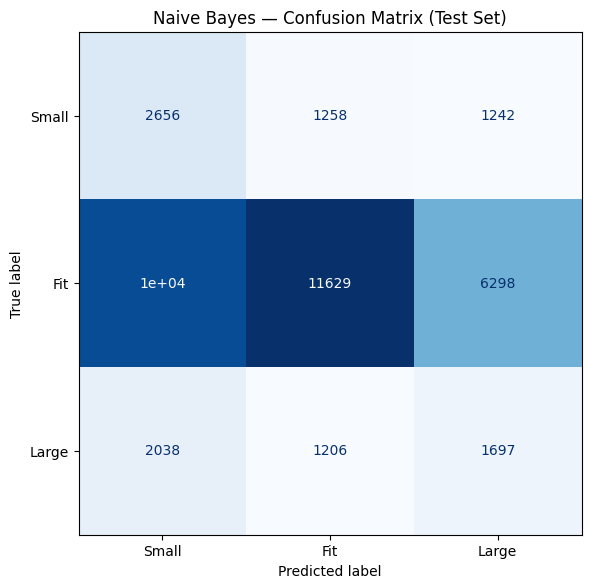

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Naive Bayes — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/naive_bayes_confusion_matrix.png", dpi=300)
plt.show()

In [20]:
nb_proba = best_nb.predict_proba(X_test)   # no wrapper needed, built-in

nb_proba_df = pd.DataFrame({
    "user_id":    df.loc[X_test.index, "user_id"],
    "item_id":    df.loc[X_test.index, "item_id"],
    "true_fit":   y_test.values,
    "prob_small": nb_proba[:, 0],
    "prob_fit":   nb_proba[:, 1],
    "prob_large": nb_proba[:, 2]
})

In [21]:
nb_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/naive_bayes_fit_probabilities.csv",
    index=False
)

In [22]:
import joblib
joblib.dump(best_nb, "../../Models/naive_bayes_fit_classifier.joblib")


['../../Models/naive_bayes_fit_classifier.joblib']

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `var_smoothing=0.1` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.46 | ~0.41 | — | — | — |
> | **fixed (new)** | **0.42** | **0.35** | 0.26 | 0.55 | 0.24 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

Naive Bayes trades majority-class dominance for balance. Instead of predicting "Fit" 95% of the time, it actually attempts all three classes:

Small went from recall 0.01 → 0.27 — it now detects over a quarter of small fits, vs. almost none before

Large went from recall 0.26 → 0.69 — much better at catching large fits

Fit dropped from recall 0.95 → 0.43 — it no longer over-predicts Fit


The accuracy is lower for Naive Bayes compared with SVM because the model stops blindly predicting the majority class (from Macro F1 )

var_smoothing=0.1 ==> It means the model needed a lot of smoothing to perform well, which suggests your features aren't perfectly Gaussian — body measurements and topic distributions likely have skewed distributions. Naive Bayes is making a strong assumption that doesn't fully hold.

Naive Bayes is more fair across classes than Linear SVM, but neither model is great. 

Both are likely underperforming because:
1. The features have complex, non-linear relationships (favouring kernel SVM or tree-based models)

2. Class imbalance is severe (174k Fit vs 34k Small)

3. The independence assumption in NB is violated by correlated body measurements